# Transfert Learning - ResNet and Cifar 100


## 1. libraries and working environment

In [1]:
# Deep Learning libraries
import torch
import torchvision
from torch.utils import data
from torchvision import datasets, models, transforms
from torchinfo import summary

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

from collections import Counter

from tqdm import tqdm

import numpy as np

import torchvision.utils as vutils
import matplotlib.pyplot as plt

In [2]:
# Check if GPU is enabled
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device: {}".format(device))

# Get specific GPU model
if str(device) == "cuda":
  print("GPU: {}".format(torch.cuda.get_device_name(0)))

Device: cuda
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design


## 2. Parameters

In [18]:
# Path to the data and the weigth (to be saved) directories 
dataset_dir = "./"
model_weigths_path = "resnet18_trans_lr_CIFAR.pth"

# Batch size to be utilized
batch_size = 32

# learning rate 
lr = 0.0001 

# number of epochs
num_epochs = 20 

# Mean tensor
im_mean = [0.4914, 0.4822, 0.4465]

# Std tensor
im_std = [0.2470, 0.2435, 0.2616]

# Loading the dataset is using x CPU threads
num_workers = 2

# splitting rate between train and validation sets
valid_rate = 0.2

# reducing the database size
reduce_rate = 10


## 3. Data
We arre going to use the CIFAR-10 (Canadian Institute for Advanced Research, 10 classes) dataset, which is an image database consisting of 60,000 color (RGB) images of 32x32 pixels (low resolution). Each of the 10 classes contains 6,000 images. In more detail, this database contains :

* The images are labelled with one of 10 mutually exclusive classes: airplane, automobile (but not truck or pickup truck), bird, cat, deer, dog, frog, horse, ship, and truck (but not pickup truck)
  
<img src="cifar_10.png" alt="CIFAR-10 classes" width="400" />


* The training set consists of 50,000 images (5,000 images per class). There is no validation set.
* The test set consists of 10,000 images (1,000 images per class).


This dataset is managed by PyTorch.


In [4]:
def Load_data(root, batch_size=32, num_workers=0, total_mean=[0.5, 0.5, 0.5], total_std=[0.2, 0.2, 0.2],valid_rate=0.2,reduce_rate=10):
    # Transforms applied to the input data
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(total_mean, total_std)])
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(), 
        transforms.Normalize(total_mean, total_std)])
    
    # Load the dataset
    trainset = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=train_transform)
    testset = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=test_transform)

    # Reduce the data sets
    torch.manual_seed(0)
    data_limit_len = round(len(trainset) /reduce_rate) # max number of images in the data
    trainset1, tr = torch.utils.data.random_split(trainset, [data_limit_len, len(trainset)-data_limit_len])
    data_limit_len = round(len(testset) /reduce_rate) # max number of images in the data
    testset1, tr = torch.utils.data.random_split(testset, [data_limit_len, len(testset)-data_limit_len])
    
    # Split trainset into train and validation sets
    nb_train = int((1.0 - valid_rate) * len(trainset1))
    nb_valid =  int(valid_rate * len(trainset1))
    train_set, valid_set = torch.utils.data.dataset.random_split(trainset1, [nb_train, nb_valid])

    #  create a dataloader
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last = True)
    valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last = True)
    test_loader = torch.utils.data.DataLoader(testset1, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last = True)

    print("The train set contains {} images, in {} batches".format(len(train_loader.dataset), len(train_loader)))
    print("The validation set contains {} images, in {} batches".format(len(valid_loader.dataset), len(valid_loader)))
    print("The test set contains {} images, in {} batches".format(len(test_loader.dataset), len(test_loader)))

    # Check how many images per class - time consuming !
    train_classes = [label for _, label in train_set]
    print("class names and associated index")
    print(trainset.class_to_idx)
    print("Number of images per class in the train set:")
    print(sorted(Counter(train_classes).items()))
    

    # Get the names of the classes
    class_names = trainset.classes
            
    return train_loader, valid_loader, test_loader, class_names
    

In [7]:
# Load the datasets
train_loader, valid_loader, test_loader, classes_names = Load_data(root=dataset_dir, batch_size=batch_size, num_workers=num_workers, total_mean=im_mean, total_std=im_std,valid_rate=valid_rate,reduce_rate=reduce_rate)

# Number of classes in the dataset
num_classes=len(classes_names)

100%|██████████| 170M/170M [00:26<00:00, 6.39MB/s] 


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified
The train set contains 4000 images, in 125 batches
The validation set contains 1000 images, in 31 batches
The test set contains 1000 images, in 31 batches
class names and associated index
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Number of images per class in the train set:
[(0, 414), (1, 401), (2, 407), (3, 403), (4, 399), (5, 390), (6, 405), (7, 380), (8, 399), (9, 402)]


### Visualize some data

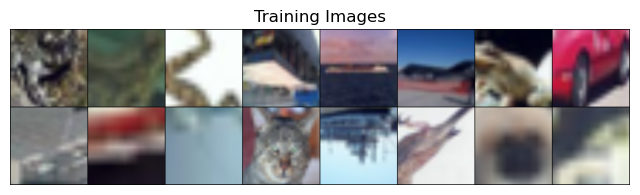

In [8]:
# Plot some training images
real_batch = next(iter(train_loader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:16], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

## 4. Model for fine tuning

For this session, we are using a convolutional network architecture that performs very well on ImageNet: the ResNet family.

Here, we are using the ResNet-50 model, which is directly implemented in PyTorch, but which needs to be adapted to our dataset.

This network has been pre-trained on ImageNet and will be used to extract image descriptors. Indeed, the representation learned by the last layers of the network normally contain information useful for their classification. This knowledge should be transferable to another dataset.

Each image of our dataset will go through the ResNEt-50 network to extract the activations obtained just before the linear layer that performs the classification in the case of ImageNet. For each image, we thus obtain a vector of size $d$ corresponding to the deep features.

1- Load the pre-trained ResNet-50 model

In [13]:
my_resnet = models.resnet18(pretrained=True)

2- Freeze all the layers of the pre-trained model

In [14]:
for param in my_resnet.parameters():
    param.requires_grad = False
    
"""
for param in my_resnet.fc.parameters():
    param.requires_grad = True
"""

'\nfor param in my_resnet.fc.parameters():\n    param.requires_grad = True\n'

3- Modify RestNet-50 head for classification task (i.e. adapt the final layer)

In [15]:
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform(m.weight)

num_ftrs = my_resnet.fc.in_features
num_classes = len(classes_names)
fc1 = torch.nn.Linear(num_ftrs, 64)
relu = torch.nn.ReLU(inplace=True)
dropout = torch.nn.Dropout(0.5)
fc2 = torch.nn.Linear(64, num_classes)
fc = torch.nn.Sequential(fc1, relu, dropout, fc2)
fc.apply(init_weights)
my_resnet.fc = fc

C:\Users\bocca\AppData\Local\Temp\ipykernel_37128\561414524.py:3: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)


4- Check the new model and the number of trainable parameters (if gpu device)

In [16]:
# set model to device 
model = my_resnet.to(device)

# Visualize the model
if str(device) == "cuda":
    print(summary(my_resnet,(batch_size, 3, 224, 224))) 
else:
    print(my_resnet)
    

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 10]                  --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]  

## 5. Train

### Metrics

In [17]:
def calculate_metric(y_test,y_test_predictions):
    accuracy = accuracy_score(y_test, y_test_predictions)
    precision = precision_score(y_test, y_test_predictions, average = 'macro', zero_division=np.nan)
    recall = recall_score(y_test, y_test_predictions, average = 'macro', zero_division=np.nan)
    f1score = f1_score(y_test, y_test_predictions, average = 'macro', zero_division=np.nan)
    return accuracy, precision, recall, f1score

### Training

In [19]:
# loss function
loss_function = torch.nn.CrossEntropyLoss() # cross entropy works well for multi-class problems

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

# Number of batches for the training and validation sets
train_batches = len(train_loader)
valid_batches = len(valid_loader)

# loop for every epoch (training + evaluation)
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    total_train_loss = 0

    # ----------------- TRAINING  -------------------- 
    # set model to training
    model.train()

    for i, data in enumerate(tqdm(train_loader)):
        X, y = data[0].to(device), data[1].to(device)
        
        # training step for single batch
        model.zero_grad()
        outputs = model(X)
        loss = loss_function(outputs, y)
        loss.backward()
        optimizer.step()

        # getting training quality data
        current_loss = loss.item()
        total_train_loss += current_loss

    # releasing unceseccary memory in GPU
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # ----------------- VALIDATION  ----------------- 
    total_val_loss = 0
    precision, recall, f1score, accuracy = [], [], [], []
    
    # set model to evaluating (testing)
    model.eval()
    with torch.no_grad():
        for i, data in enumerate(valid_loader):
            X, y = data[0].to(device), data[1].to(device)

            outputs = model(X) # this get's the prediction from the network
            loss = loss_function(outputs, y)

            # getting validation quality data
            current_loss = loss.item()
            total_val_loss += current_loss

            predicted_classes = torch.max(outputs, 1)[1] # get class from network's prediction
            
            # calculate P/R/F1/A metrics for batch
            acc, prec, rec, f1s = calculate_metric(y.cpu(), predicted_classes.cpu())
            
            accuracy.append(acc)
            precision.append(prec)
            recall.append(rec)
            f1score.append(f1s)
          
    print(f"Epoch {epoch+1}/{num_epochs}, training loss: {total_train_loss/train_batches}, validation loss: {total_val_loss/valid_batches}")
    print(f"Accuracy =  %.4f, Precision =  %.4f, Recall =  %.4f, F1Score =  %.4f" % (np.sum(accuracy)/valid_batches, np.sum(precision)/valid_batches, np.sum(recall)/valid_batches, np.sum(f1score)/valid_batches))
    train_losses.append(total_train_loss/train_batches) # for plotting learning curve
    valid_losses.append(total_val_loss/valid_batches)

100%|██████████| 125/125 [00:27<00:00,  4.58it/s]


Epoch 1/20, training loss: 2.311508701324463, validation loss: 2.1848371182718584
Accuracy =  0.2228, Precision =  0.2366, Recall =  0.2069, F1Score =  0.1565


100%|██████████| 125/125 [00:18<00:00,  6.61it/s]


Epoch 2/20, training loss: 2.141858016014099, validation loss: 1.957956817842299
Accuracy =  0.2873, Precision =  0.2779, Recall =  0.2851, F1Score =  0.2324


100%|██████████| 125/125 [00:24<00:00,  5.01it/s]


...

Epoch 18/20, training loss: 1.7233066062927247, validation loss: 1.481170162077873
Accuracy =  0.4718, Precision =  0.5198, Recall =  0.4811, F1Score =  0.4324


100%|██████████| 125/125 [00:19<00:00,  6.27it/s]


Epoch 19/20, training loss: 1.7254873542785645, validation loss: 1.5117567739179056
Accuracy =  0.4859, Precision =  0.4840, Recall =  0.4843, F1Score =  0.4318


100%|██████████| 125/125 [00:18<00:00,  6.67it/s]


Epoch 20/20, training loss: 1.737803253173828, validation loss: 1.4608091577406852
Accuracy =  0.4909, Precision =  0.4964, Recall =  0.4854, F1Score =  0.4328


### Display the losses

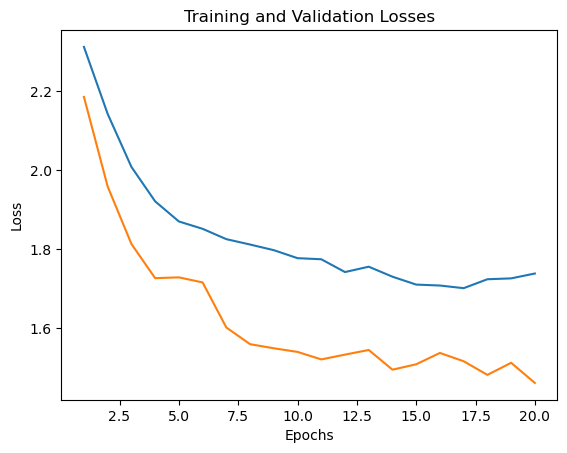

In [20]:
# Generate a sequence of integers to represent the epoch numbers
epochs = range(1, num_epochs+1)

# Plot and label the training and validation loss values
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, valid_losses, label='Validation Loss')

# Add in a title and axes labels
plt.title('Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

### Save the learned model

In [21]:
torch.save(model.state_dict(), model_weigths_path)     

In [25]:
loss_function = torch.nn.CrossEntropyLoss() # cross entropy works well for multi-class problems
my_resnet.to(device)
# releasing unceseccary memory in GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    
nb_test_batches = len(test_loader)

with torch.no_grad():
    my_resnet.eval()
    total_test_loss = 0
    precision, recall, f1score, accuracy = [], [], [], []
    for (input, target) in test_loader:
        input = input.to(device)
        target = target.to(device)
        output = my_resnet(input)
        loss = loss_function(output, target)
        total_test_loss += loss.item()
        predicted_classes = torch.max(output, 1)[1] # get class from network's prediction
            
        # calculate P/R/F1/A metrics for batch
        acc, prec, rec, f1s = calculate_metric(target.cpu(), predicted_classes.cpu())
        accuracy.append(acc)
        precision.append(prec)
        recall.append(rec)
        f1score.append(f1s)
        
    print(f"Test loss: {total_test_loss/nb_test_batches}")
    print(f"Accuracy =  %.4f, Precision =  %.4f, Recall =  %.4f, F1Score =  %.4f" % (np.sum(accuracy)/nb_test_batches, np.sum(precision)/nb_test_batches, np.sum(recall)/nb_test_batches, np.sum(f1score)/nb_test_batches))

Test loss: 1.2592176987278847
Accuracy =  0.5968, Precision =  0.6093, Recall =  0.6121, F1Score =  0.5489


## from scratch

In [26]:
my_resnet2 = models.resnet18(pretrained=False)
num_ftrs = my_resnet2.fc.in_features
num_classes = len(classes_names)
fc1 = torch.nn.Linear(num_ftrs, 64)
relu = torch.nn.ReLU(inplace=True)
dropout = torch.nn.Dropout(0.5)
fc2 = torch.nn.Linear(64, num_classes)
fc = torch.nn.Sequential(fc1, relu, dropout, fc2)
fc.apply(init_weights)
my_resnet2.fc = fc

C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\bocca\AppData\Local\Temp\ipykernel_37128\561414524.py:3: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)


In [27]:
# set model to device 
model = my_resnet2.to(device)

# Visualize the model
if str(device) == "cuda":
    print(summary(my_resnet2,(batch_size, 3, 224, 224))) 
else:
    print(my_resnet2)

# loss function
loss_function = torch.nn.CrossEntropyLoss() # cross entropy works well for multi-class problems

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

# Number of batches for the training and validation sets
train_batches = len(train_loader)
valid_batches = len(valid_loader)

# loop for every epoch (training + evaluation)
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    total_train_loss = 0

    # ----------------- TRAINING  -------------------- 
    # set model to training
    model.train()

    for i, data in enumerate(tqdm(train_loader)):
        X, y = data[0].to(device), data[1].to(device)
        
        # training step for single batch
        model.zero_grad()
        outputs = model(X)
        loss = loss_function(outputs, y)
        loss.backward()
        optimizer.step()

        # getting training quality data
        current_loss = loss.item()
        total_train_loss += current_loss

    # releasing unceseccary memory in GPU
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # ----------------- VALIDATION  ----------------- 
    total_val_loss = 0
    precision, recall, f1score, accuracy = [], [], [], []
    
    # set model to evaluating (testing)
    model.eval()
    with torch.no_grad():
        for i, data in enumerate(valid_loader):
            X, y = data[0].to(device), data[1].to(device)

            outputs = model(X) # this get's the prediction from the network
            loss = loss_function(outputs, y)

            # getting validation quality data
            current_loss = loss.item()
            total_val_loss += current_loss

            predicted_classes = torch.max(outputs, 1)[1] # get class from network's prediction
            
            # calculate P/R/F1/A metrics for batch
            acc, prec, rec, f1s = calculate_metric(y.cpu(), predicted_classes.cpu())
            
            accuracy.append(acc)
            precision.append(prec)
            recall.append(rec)
            f1score.append(f1s)
          
    print(f"Epoch {epoch+1}/{num_epochs}, training loss: {total_train_loss/train_batches}, validation loss: {total_val_loss/valid_batches}")
    print(f"Accuracy =  %.4f, Precision =  %.4f, Recall =  %.4f, F1Score =  %.4f" % (np.sum(accuracy)/valid_batches, np.sum(precision)/valid_batches, np.sum(recall)/valid_batches, np.sum(f1score)/valid_batches))
    train_losses.append(total_train_loss/train_batches) # for plotting learning curve
    valid_losses.append(total_val_loss/valid_batches)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 10]                  --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│

100%|██████████| 125/125 [00:37<00:00,  3.29it/s]


Epoch 1/20, training loss: 2.2861284046173096, validation loss: 2.090564931592634
Accuracy =  0.2077, Precision =  0.2256, Recall =  0.2089, F1Score =  0.1292


100%|██████████| 125/125 [00:34<00:00,  3.62it/s]


Epoch 2/20, training loss: 2.150618601799011, validation loss: 2.053115971626774
Accuracy =  0.2157, Precision =  0.2254, Recall =  0.2114, F1Score =  0.1441


...

Epoch 18/20, training loss: 1.9783758239746094, validation loss: 1.972436039678512
Accuracy =  0.2399, Precision =  0.2410, Recall =  0.2360, F1Score =  0.1845


100%|██████████| 125/125 [00:34<00:00,  3.65it/s]


Epoch 19/20, training loss: 2.003937828063965, validation loss: 1.9091366875556208
Accuracy =  0.2389, Precision =  0.2481, Recall =  0.2429, F1Score =  0.1866


100%|██████████| 125/125 [00:33<00:00,  3.69it/s]


Epoch 20/20, training loss: 1.9864746894836425, validation loss: 1.9085279241684945
Accuracy =  0.2520, Precision =  0.2438, Recall =  0.2545, F1Score =  0.1752


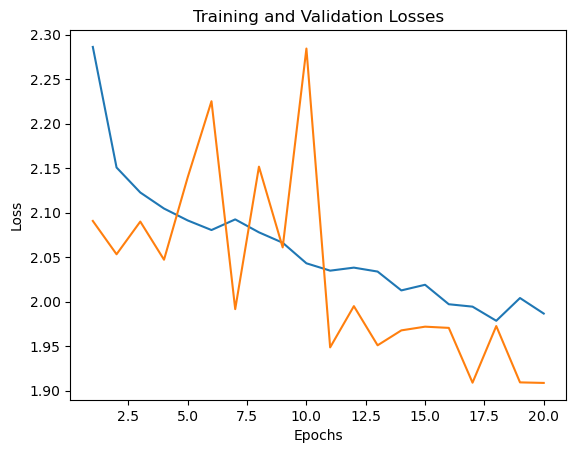

In [28]:
# Generate a sequence of integers to represent the epoch numbers
epochs = range(1, num_epochs+1)

# Plot and label the training and validation loss values
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, valid_losses, label='Validation Loss')

# Add in a title and axes labels
plt.title('Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [29]:
torch.save(model.state_dict(), "resnet18_from_scratch_CIFAR.pth") 